# Sesión 2 · Funciones de valor, Bellman, SARSA y Q-learning


**Máster en IA · Reinforcement Learning**

---

## Qué vamos a hacer en este notebook

En la sesión 1 vimos la intuición general de RL:

- agente,
- entorno,
- estado,
- acción,
- recompensa,
- episodio,
- retorno,
- política,
- exploración frente a explotación.

También asomó una primera idea importante:

> no basta con actuar; necesitamos una forma de **valorar** estados y acciones.

En esta sesión vamos a profundizar justo en eso.

### Objetivos de la sesión

Al terminar este notebook deberías ser capaz de entender con bastante claridad:

- qué significa la **función de valor de estado** `V(s)`,
- qué significa la **función de valor de acción** `Q(s, a)`,
- por qué las **ecuaciones de Bellman** son el corazón del RL clásico,
- cómo se pasa de una política fija a una política mejor,
- cómo funcionan las actualizaciones **TD**,
- en qué se diferencian **SARSA** y **Q-learning**,
- qué papel juegan `alpha`, `gamma` y `epsilon`,
- y por qué dos algoritmos parecidos pueden aprender comportamientos distintos.

Como en los notebooks que nos gustan en esta asignatura, iremos alternando:

- explicación conceptual muy pausada,
- pequeños ejemplos con cuentas sencillas,
- celdas de código muy cortas para inspeccionar salidas,
- y después piezas un poco más completas donde el agente ya aprende.

# 1. Antes de empezar: la idea clave de hoy

En RL no queremos solo decir:

- "he recibido una recompensa ahora"

sino más bien:

- "¿qué **promesa de futuro** tiene este estado?"
- "¿qué **promesa de futuro** tiene esta acción en este estado?"

Esa es la gran transición conceptual de esta sesión.

## Recompensa inmediata vs valor

La recompensa inmediata responde a algo local:

> "¿qué he ganado o perdido en este paso?"

El valor responde a algo mucho más estratégico:

> "si estoy aquí, ¿cómo de bueno es este punto pensando en lo que puede venir después?"

Eso significa que un estado puede tener:

- recompensa inmediata aparentemente pequeña,
- pero mucho valor si está muy cerca de una buena secuencia futura.

Y también al revés:

- un paso puede parecer neutro,
- pero llevar a un callejón horrible unos movimientos después.

In [2]:
recompensas = {
    "pisar casilla normal": -0.1,
    "llegar a la meta": 10.0,
    "caer en trampa": -5.0
}


for evento, valor in recompensas.items():
    print(f"{evento:20s} -> {valor:+.1f}")

pisar casilla normal -> -0.1
llegar a la meta     -> +10.0
caer en trampa       -> -5.0


La tabla anterior solo habla de **recompensa inmediata**.

Pero imagina dos estados distintos:

- uno está lejos de la meta,
- otro está a un solo paso de la meta.

Aunque ambos tengan recompensa inmediata `-0.1` al pisarlos, intuitivamente **no valen lo mismo**.

Eso nos lleva a `V(s)`.

# 2. Un primer entorno para pensar con calma: TinyLineGrid

Antes de ir a un GridWorld más interesante, vamos a usar un mini-entorno *grid-based* casi de juguete.

Será una rejilla de una sola fila:

```text
S  .  .  G
```

- `S`: estado inicial
- `.`: casilla normal
- `G`: meta

Las acciones posibles serán:

- izquierda
- derecha



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(suppress=True, precision=3)

In [4]:
ACTIONS = {
    0: "izquierda",
    1: "derecha",
}

for k, v in ACTIONS.items():
    print(k, "->", v)

0 -> izquierda
1 -> derecha


In [5]:
@dataclass
class StepResult:
    next_state: tuple
    reward: float
    terminated: bool


class TinyLineGrid:
    def __init__(self, length=4, step_cost=-0.1, goal_reward=1.0):
        self.length = length
        self.step_cost = step_cost
        self.goal_reward = goal_reward
        self.start = (0, 0)
        self.goal = (0, length - 1)
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        col = self.state[1]

        if action == 0:  # izquierda
            new_col = max(0, col - 1)
        elif action == 1:  # derecha
            new_col = min(self.length - 1, col + 1)
        else:
            raise ValueError("Acción no válida")

        self.state = (0, new_col)

        if self.state == self.goal:
            return StepResult(self.state, self.goal_reward, True)
        else:
            return StepResult(self.state, self.step_cost, False)

    def render_text(self):
        row = []
        for c in range(self.length):
            pos = (0, c)
            if pos == self.state:
                row.append("A")
            elif pos == self.start:
                row.append("S")
            elif pos == self.goal:
                row.append("G")
            else:
                row.append(".")
        print(" ".join(row))

In [6]:
env = TinyLineGrid(length=4, step_cost=-0.1, goal_reward=1.0)
estado = env.reset()
print("Estado inicial:", estado)
env.render_text()

Estado inicial: (0, 0)
A . . G


In [7]:
resultado = env.step(1)  # derecha
print("Nuevo estado:", resultado.next_state)
print("Recompensa:", resultado.reward)
print("¿Terminado?:", resultado.terminated)
env.render_text()

Nuevo estado: (0, 1)
Recompensa: -0.1
¿Terminado?: False
S A . G


Obsérvese lo siguiente:

- al movernos a la derecha desde el inicio, **no llegamos todavía a la meta**,
- por tanto la recompensa sigue siendo el pequeño coste de paso `-0.1`,
- pero intuitivamente estamos mejor posicionados que antes.

Ese "estar mejor posicionados" es la intuición de valor.

# 3. Retorno y descuento: el futuro no siempre pesa igual

Recordemos la definición de retorno descontado:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots
$$
donde:

- `R_{t+1}` es la recompensa inmediata,
- `gamma` (o `γ`) es el factor de descuento.

## ¿Para qué sirve `gamma`?

`gamma` controla cuánto nos importa el futuro:

- si `gamma = 0`, solo importa la recompensa inmediata;
- si `gamma` está cerca de `1`, el futuro pesa mucho;
- si `gamma` es más pequeño, el futuro se va "apagando" rápido.

Vamos a ver un ejemplo diminuto.

In [8]:
recompensas_futuras = [-0.1, -0.1, 1.0]

for gamma in [0.0, 0.5, 0.9, 0.99]:
    retorno = sum((gamma**i) * r for i, r in enumerate(recompensas_futuras))
    print(f"gamma={gamma:>4} -> retorno={retorno:.4f}")

gamma= 0.0 -> retorno=-0.1000
gamma= 0.5 -> retorno=0.1000
gamma= 0.9 -> retorno=0.6200
gamma=0.99 -> retorno=0.7811


Aquí la secuencia de recompensas era:

- primer paso: `-0.1`
- segundo paso: `-0.1`
- tercer paso: `+1.0`

Fíjate en la interpretación:

- con `gamma = 0`, el premio final **no cuenta nada**;
- con `gamma = 0.9` o `0.99`, sí cuenta bastante;
- por tanto, `gamma` es una forma de decirle al agente cuánto debe pensar "a largo plazo".

## Cálculo manual de un retorno

Imaginemos que desde cierto estado hacemos tres movimientos y obtenemos:

$$
[-0.1,\,-0.1,\,+1.0]
$$

Si `gamma = 0.9`, entonces:

$$
G = -0.1 + 0.9(-0.1) + 0.9^2(1.0)
$$

Vamos a comprobarlo con código.

In [9]:
gamma = 0.9
retorno = -0.1 + gamma * (-0.1) + (gamma**2) * 1.0
retorno

0.6200000000000001

Este número resume **toda la secuencia futura** en una sola cantidad.

Y ahora viene el salto importante:

> `V(s)` es, esencialmente, el retorno esperado si empiezo en el estado `s` y sigo una política dada.

# 4. Función de valor de estado `V(s)`

La función de valor de estado responde a esta pregunta:

> "Si estoy en el estado `s` y sigo la política `π`, ¿qué retorno esperado obtengo?"

Se suele escribir como:

$$
V^\pi(s)
$$


y se lee:

- "valor del estado `s` bajo la política `π`"

## Muy importante

`V(s)` **no es una recompensa inmediata**.

Es una medida de lo prometedor que es un estado, **asumiendo que después actuaré siguiendo cierta política**.

Esto último es fundamental:

- el valor no existe "en el vacío",
- el valor depende de cómo nos comportemos después.

In [10]:
def politica_derecha_si_puede(state):
    # En esta rejilla de una sola fila, siempre intentamos ir a la derecha.
    return 1

env = TinyLineGrid(length=4, step_cost=-0.1, goal_reward=1.0)
state = env.reset()

trayectoria = []
terminated = False

while not terminated:
    action = politica_derecha_si_puede(state)
    result = env.step(action)
    trayectoria.append((state, ACTIONS[action], result.reward, result.next_state))
    state = result.next_state
    terminated = result.terminated

for paso, item in enumerate(trayectoria, start=1):
    s, a, r, s_next = item
    print(f"Paso {paso}: estado={s}, acción={a}, recompensa={r:+.1f}, siguiente={s_next}")

Paso 1: estado=(0, 0), acción=derecha, recompensa=-0.1, siguiente=(0, 1)
Paso 2: estado=(0, 1), acción=derecha, recompensa=-0.1, siguiente=(0, 2)
Paso 3: estado=(0, 2), acción=derecha, recompensa=+1.0, siguiente=(0, 3)


Con esta política, desde el estado inicial la secuencia es muy sencilla:

- derecha,
- derecha,
- derecha,
- meta.

Así que, si esta política fuese determinista y el entorno también, el valor del estado inicial podría calcularse directamente a partir del retorno de esa secuencia.

In [11]:
gamma = 0.9

recompensas = [-0.1, -0.1, 1.0]
valor_estimado_inicio = sum((gamma**i) * r for i, r in enumerate(recompensas))
valor_estimado_inicio

0.62

En este ejemplo tan pequeño:

- el valor del inicio bajo esa política concreta es ese número,
- porque siempre se sigue la misma ruta,
- y no hay incertidumbre.

En problemas más grandes:

- puede haber varias trayectorias posibles,
- puede haber aleatoriedad,
- y entonces hablamos de **retorno esperado**.

# 5. Bellman desde la intuición

La ecuación de Bellman es una de las ideas más importantes de todo RL.

Su intuición es preciosa y simple:

> el valor de un estado se puede descomponer en
> **recompensa inmediata + valor descontado del siguiente estado**.

Es decir, para una política fija:

$$
V^\pi(s) = \mathbb{E}_\pi [R_{t+1} + \gamma V^\pi(S_{t+1}) \mid S_t=s]
$$

## Traducción a lenguaje normal

"El valor de donde estoy ahora" es:

- lo que espero ganar en el siguiente paso,
- más el valor futuro de donde acabaré,
- descontado por `gamma`.

## Idea general

La ecuación

$$
V^\pi(s) = \mathbb{E}_\pi [R_{t+1} + \gamma V^\pi(S_{t+1}) \mid S_t=s]
$$

es la **ecuación de Bellman** para una política $\pi$, y expresa el valor de un estado de forma recursiva: lo que ganas ahora más lo que esperas ganar después.


Se usa en aprendizaje por refuerzo para medir qué tan “bueno” es estar en un estado si el agente sigue una política concreta. 

## Término por término

- $V^\pi(s)$: es “lo bueno que es” estar en el estado $s$ si, a partir de ahí, sigues la política $\pi$. Dicho de forma informal, es la ganancia total esperada desde ese estado. 
- $\pi$: es la política, o sea, la forma de actuar del agente; indica qué acciones tiende a tomar en cada estado. 
- $\mathbb{E}_\pi[\cdot]$: significa **valor esperado** o promedio ponderado por probabilidades, asumiendo que el agente actúa según $\pi$. 
- $R_{t+1}$: es la recompensa inmediata que llega justo después de estar en el estado actual y hacer una acción.
- $\gamma$: es el factor de descuento, un número entre 0 y 1 que dice cuánto importan las recompensas futuras frente a las inmediatas. Si $\gamma$ es grande, el agente piensa más a largo plazo. 
- $V^\pi(S_{t+1})$: es el valor del siguiente estado al que llegas. O sea, después de este paso, cuánto promete el futuro desde el nuevo estado. 
- $S_{t+1}$: es el siguiente estado.
- $\mid S_t = s$: significa “suponiendo que ahora mismo estamos en el estado $s$”. [

## Traducción humana

Leído como frase, sería algo así: **“Si ahora estoy en $s$, el valor de este estado es el promedio de recibir una recompensa en el siguiente paso y, además, el valor del estado al que voy después, reducido por $\gamma$”**. 
O aún más simple: **“valor actual = premio de ahora + futuro esperado descontado”**. 

## Ejemplo rápido

Imagina un juego donde desde un estado puedes ganar 10 puntos ahora y luego pasar a un estado cuyo valor esperado es 20. Si $\gamma = 0.9$, entonces la idea de la ecuación sería: valor actual = 10 + 0.9 por 20 = 28. 
No significa que siempre pase exactamente eso, sino que hablamos de un promedio esperado teniendo en cuenta la incertidumbre y las decisiones de la política. 

## Intuición útil

Esta ecuación es recursiva porque el valor de un estado depende del valor del siguiente estado. 
Por eso Bellman permite “descomponer” un problema largo en pasos pequeños: mirar qué obtienes ahora y cuánto vale continuar desde el siguiente punto. 



## Un mini ejemplo completamente manual

Supongamos esta línea:

```text
(0,0) -> (0,1) -> (0,2) -> G
```

y que la política siempre hace:

- derecha, derecha, derecha.

Con `gamma = 0.9`, paso cost `-0.1` y recompensa final `+1.0`.

Entonces:

- `V(G) = 0` si consideramos que una vez terminal no hay más futuro,
- `V((0,2)) = 1.0`
- `V((0,1)) = -0.1 + 0.9 * 1.0 = 0.8`
- `V((0,0)) = -0.1 + 0.9 * 0.8 = 0.62`

Vamos a calcularlo en código exactamente así.

In [12]:
gamma = 0.9
V_goal = 0.0
V_02 = 1.0
V_01 = -0.1 + gamma * V_02
V_00 = -0.1 + gamma * V_01

print("V((0,2)) =", V_02)
print("V((0,1)) =", V_01)
print("V((0,0)) =", V_00)

V((0,2)) = 1.0
V((0,1)) = 0.8
V((0,0)) = 0.6200000000000001


Fíjate en la magia conceptual:

- no hemos necesitado "simular todo desde cero" una y otra vez,
- hemos ido **propagando valor hacia atrás**.

Esa idea de "hacer backups" o "retropropagar promesa de futuro" aparece todo el rato en RL.

# 6. Un GridWorld un poco más interesante

Ahora vamos a usar una rejilla 4x4 con:

- inicio,
- meta,
- trampa,
- pared,
- coste por paso.

La sesión de hoy necesita un entorno donde tenga sentido hablar de:

- estados mejores y peores,
- rutas seguras y arriesgadas,
- políticas distintas,
- y aprendizaje real con tablas `V` y `Q`.

In [13]:
ACTIONS_4 = {
    0: "arriba",
    1: "derecha",
    2: "abajo",
    3: "izquierda",
}

DELTA_4 = {
    0: (-1, 0),
    1: (0, 1),
    2: (1, 0),
    3: (0, -1),
}

In [14]:
@dataclass
class GridStep:
    next_state: tuple
    reward: float
    terminated: bool


class DidacticGridWorld:
    def __init__(self, rows=4, cols=4, step_cost=-0.04, goal_reward=1.0, trap_reward=-1.0):
        self.rows = rows
        self.cols = cols
        self.step_cost = step_cost
        self.goal_reward = goal_reward
        self.trap_reward = trap_reward

        self.start = (3, 0)
        self.goal = (0, 3)
        self.trap = (1, 3)
        self.wall = (1, 1)

        self.state = self.start

        self.states = [
            (r, c)
            for r in range(self.rows)
            for c in range(self.cols)
            if (r, c) != self.wall
        ]

    def reset(self):
        self.state = self.start
        return self.state

    def is_terminal(self, state):
        return state == self.goal or state == self.trap

    def step_from_state(self, state, action):
        if self.is_terminal(state):
            return GridStep(state, 0.0, True)

        dr, dc = DELTA_4[action]
        nr, nc = state[0] + dr, state[1] + dc

        if not (0 <= nr < self.rows and 0 <= nc < self.cols):
            nr, nc = state

        if (nr, nc) == self.wall:
            nr, nc = state

        next_state = (nr, nc)

        if next_state == self.goal:
            return GridStep(next_state, self.goal_reward, True)
        elif next_state == self.trap:
            return GridStep(next_state, self.trap_reward, True)
        else:
            return GridStep(next_state, self.step_cost, False)

    def step(self, action):
        result = self.step_from_state(self.state, action)
        self.state = result.next_state
        return result

    def render_text(self, values=None, policy=None):
        for r in range(self.rows):
            row_items = []
            for c in range(self.cols):
                s = (r, c)
                if s == self.wall:
                    txt = "#####"
                elif self.state == s:
                    txt = "  A  "
                elif s == self.start:
                    txt = "  S  "
                elif s == self.goal:
                    txt = "  G  "
                elif s == self.trap:
                    txt = "  X  "
                elif values is not None:
                    txt = f"{values.get(s, 0):5.2f}"
                elif policy is not None:
                    txt = f"  {policy.get(s, '?')}  "
                else:
                    txt = "  .  "
                row_items.append(txt)
            print(" ".join(row_items))
        print()

    def plot_values(self, values, title="Valores de estado"):
        grid = np.full((self.rows, self.cols), np.nan)
        for s, v in values.items():
            grid[s] = v
        plt.figure(figsize=(6, 5))
        plt.imshow(grid)
        plt.colorbar()
        for r in range(self.rows):
            for c in range(self.cols):
                if (r, c) == self.wall:
                    plt.text(c, r, "WALL", ha="center", va="center")
                elif (r, c) == self.goal:
                    plt.text(c, r, f"G\n{grid[r,c]:.2f}", ha="center", va="center")
                elif (r, c) == self.trap:
                    plt.text(c, r, f"X\n{grid[r,c]:.2f}", ha="center", va="center")
                elif not np.isnan(grid[r, c]):
                    plt.text(c, r, f"{grid[r,c]:.2f}", ha="center", va="center")
        plt.title(title)
        plt.xticks(range(self.cols))
        plt.yticks(range(self.rows))
        plt.show()

    def available_actions(self, state=None):
        return list(ACTIONS_4.keys())

In [15]:
env = DidacticGridWorld()
estado = env.reset()
print("Estado inicial:", estado)
env.render_text()

Estado inicial: (3, 0)
  .     .     .     G  
  .   #####   .     X  
  .     .     .     .  
  A     .     .     .  



Conviene visualizar mentalmente la rejilla:

- `S` = inicio
- `G` = goal / meta
- `X` = trampa
- `#####` = pared

Este entorno es pequeño, pero ya tiene suficiente estructura para aprender cosas interesantes.

In [16]:
env = DidacticGridWorld()
env.render_text()

  .     .     .     G  
  .   #####   .     X  
  .     .     .     .  
  A     .     .     .  



# 7. Definimos una política fija y la evaluamos

Primero no vamos a aprender nada.

Primero vamos a suponer que ya tenemos una política fija, hecha "a mano", y queremos saber:

> "¿qué valor tiene cada estado si seguimos siempre esa política?"

Eso se llama **policy evaluation**.

## Política artesanal

Vamos a definir una política bastante razonable:

- intentar ir hacia la derecha y hacia arriba para buscar la meta,
- evitando la pared cuando moleste.

In [17]:
ARROWS = {
    0: "↑",
    1: "→",
    2: "↓",
    3: "←",
}

policy_manual = {
    (3, 0): 1,  # derecha
    (3, 1): 1,
    (3, 2): 0,  # arriba
    (3, 3): 0,
    (2, 0): 1,
    (2, 1): 1,
    (2, 2): 1,
    (2, 3): 0,
    (1, 0): 0,
    (1, 2): 0,
    (0, 0): 1,
    (0, 1): 1,
    (0, 2): 1,
}

policy_symbols = {s: ARROWS[a] for s, a in policy_manual.items()}
env.render_text(policy=policy_symbols)

  →     →     →     G  
  ↑   #####   ↑     X  
  →     →     →     ↑  
  A     →     ↑     ↑  



Esta política no está "aprendida".  
La hemos escrito nosotros.

Eso es útil porque separa dos problemas:

1. **evaluar** una política,
2. **mejorar** una política.

Primero vamos con el punto 1.

# 8. Monte Carlo para estimar `V(s)` de una política fija

Una forma muy intuitiva de estimar `V(s)` es:

- arrancar episodios desde el estado `s`,
- seguir la política,
- calcular el retorno total,
- promediar muchos episodios.

Eso es una idea estilo **Monte Carlo**.

En un entorno determinista como este, bastarán pocas simulaciones para ver la lógica.

In [18]:
def run_episode_from_state(env, start_state, policy, gamma=0.9, max_steps=50):
    state = start_state
    total_return = 0.0
    discount = 1.0

    for _ in range(max_steps):
        if env.is_terminal(state):
            break

        action = policy[state]
        result = env.step_from_state(state, action)

        total_return += discount * result.reward
        discount *= gamma
        state = result.next_state

        if result.terminated:
            break

    return total_return

In [19]:
env = DidacticGridWorld()
gamma = 0.9

for s in [(3, 0), (2, 0), (0, 2)]:
    g = run_episode_from_state(env, s, policy_manual, gamma=gamma)
    print(f"Estado {s} -> retorno siguiendo la política manual = {g:.4f}")

Estado (3, 0) -> retorno siguiendo la política manual = -0.7937
Estado (2, 0) -> retorno siguiendo la política manual = -0.8374
Estado (0, 2) -> retorno siguiendo la política manual = 1.0000


Como el entorno y la política son deterministas:

- el retorno desde un estado dado siempre sale igual,
- así que en este caso el promedio coincide con ese valor directamente.

En entornos estocásticos necesitaríamos muchas trayectorias para estimar el valor esperado con cierta estabilidad.

# 9. Policy Evaluation iterativa: Bellman en acción

Ahora viene una técnica más importante para RL clásico.

En vez de simular episodios completos una y otra vez, podemos iterar usando Bellman:

$$
V(s) \leftarrow R_{t+1} + \gamma V(s')
$$

si la política es determinista y el siguiente estado está totalmente determinado.

## ¿Qué haremos?

1. Inicializamos todos los valores a 0.
2. Recorremos los estados.
3. Aplicamos un **backup de Bellman**.
4. Repetimos muchas veces.
5. Los valores van convergiendo.

In [20]:
def evaluate_policy_iterative(env, policy, gamma=0.9, theta=1e-6, max_iterations=10_000):
    V = {s: 0.0 for s in env.states}

    for iteration in range(max_iterations):
        delta = 0.0
        new_V = V.copy()

        for s in env.states:
            if env.is_terminal(s):
                new_V[s] = 0.0
                continue

            a = policy[s]
            result = env.step_from_state(s, a)
            target = result.reward + gamma * V[result.next_state] * (not result.terminated)

            delta = max(delta, abs(target - V[s]))
            new_V[s] = target

        V = new_V

        if delta < theta:
            print(f"Convergencia alcanzada en iteración {iteration + 1}")
            break

    return V

In [21]:
env = DidacticGridWorld()
V_manual = evaluate_policy_iterative(env, policy_manual, gamma=0.9)
V_manual

Convergencia alcanzada en iteración 6


{(0, 0): 0.734,
 (0, 1): 0.86,
 (0, 2): 1.0,
 (0, 3): 0.0,
 (1, 0): 0.6205999999999999,
 (1, 2): 0.86,
 (1, 3): 0.0,
 (2, 0): -0.8374000000000001,
 (2, 1): -0.8860000000000001,
 (2, 2): -0.9400000000000001,
 (2, 3): -1.0,
 (3, 0): -0.7936600000000001,
 (3, 1): -0.8374000000000001,
 (3, 2): -0.8860000000000001,
 (3, 3): -0.9400000000000001}

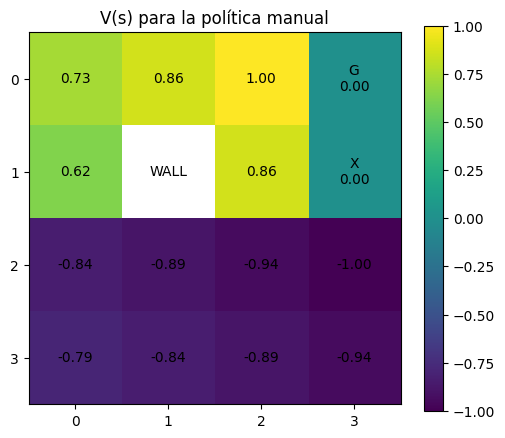

In [22]:
env.plot_values(V_manual, title="V(s) para la política manual")

Esta figura es muy importante.

Nos está diciendo, para **cada estado**, cuánto retorno esperamos obtener si seguimos la política manual.

### Cómo leerla

- valores altos: estados prometedores,
- valores bajos o negativos: estados peores,
- el gradiente de color suele mostrar cómo la promesa de futuro se propaga por la rejilla.

Fíjate en que las casillas cercanas a la meta suelen tener más valor que las lejanas.

## Inspección textual de los valores

A veces una tabla pequeña ayuda más que una imagen.

In [23]:
for s in sorted(V_manual):
    print(f"{s}: {V_manual[s]: .4f}")

(0, 0):  0.7340
(0, 1):  0.8600
(0, 2):  1.0000
(0, 3):  0.0000
(1, 0):  0.6206
(1, 2):  0.8600
(1, 3):  0.0000
(2, 0): -0.8374
(2, 1): -0.8860
(2, 2): -0.9400
(2, 3): -1.0000
(3, 0): -0.7937
(3, 1): -0.8374
(3, 2): -0.8860
(3, 3): -0.9400


# 10. Value Iteration: mejorar sin que la política venga dada

Hasta ahora hemos evaluado una política fija.

Pero en RL normalmente queremos algo mejor:

> encontrar la mejor política posible.

Una idea potente es sustituir el "seguir la política dada" por:

> en cada estado, asumir que elegiré la mejor acción disponible.

Eso nos lleva a la ecuación de optimalidad de Bellman:

$$
V^*(s) = \max_a \left[ r(s,a,s') + \gamma V^*(s') \right]
$$

En otras palabras:

- para valorar un estado,
- miro todas las acciones posibles,
- calculo qué pasaría con cada una,
- y me quedo con la mejor.

### OPTIMALIDAD DE BELLMAN PARA DUMMIES (INTERLUDIO)

Primero recuerda la ecuación:

$$
V^*(s) = \max_a \left[ r(s,a,s') + \gamma V^*(s') \right]
$$

Ahora vamos término por término.

---

## Significado de cada término

### ( $s$ ) — estado actual

Es el **estado en el que está el agente ahora mismo**.

En un **gridworld**, sería por ejemplo:

* la celda `(2,3)`
* la posición del agente en el tablero

Ejemplo:

```
. . . .
. A . .
. . G .
```

Aquí el estado podría ser:

```
s = (1,1)
```

---

### ( $a$ ) — acción

Es **una acción posible desde ese estado**.

En un gridworld normalmente son:

* `up`
* `down`
* `left`
* `right`

Por ejemplo, desde `(1,1)` el agente puede intentar:

```
a = right
```

---

### ( $s'$ ) — siguiente estado

Es el **estado al que llegamos después de ejecutar la acción**.

Ejemplo:

```
s = (1,1)
a = right
```

entonces

```
s' = (1,2)
```

---

### ( $r(s,a,s')$ ) — recompensa inmediata

Es la **recompensa que recibimos al hacer esa transición**.

Depende del problema.

Ejemplos típicos en gridworld:

| transición     | recompensa |
| -------------- | ---------- |
| moverse        | -1         |
| llegar a meta  | +10        |
| caer en trampa | -10        |

Ejemplo:

```
r((1,1), right, (1,2)) = -1
```

---

### ( $\gamma$ ) — discount factor

Es un número entre **0 y 1**:

$$
0 \le \gamma < 1
$$

Indica **cuánto nos importan las recompensas futuras**.

Ejemplos:

| γ    | significado                          |
| ---- | ------------------------------------ |
| 0    | solo importa la recompensa inmediata |
| 0.5  | futuro importa poco                  |
| 0.9  | futuro importa bastante              |
| 0.99 | futuro casi igual que presente       |

Ejemplo:

```
γ = 0.9
```

---

### ( $V^*(s')$ ) — valor del siguiente estado

Es **cuán bueno es el estado al que llegamos**, suponiendo que desde ahí actuaremos **de forma óptima**.

Es decir:

> la recompensa esperada total que podemos obtener desde ese estado.

Ejemplo:

```
V*(2,2) = 7.3
```

significa que desde `(2,2)` el agente puede obtener aproximadamente **7.3 de recompensa futura esperada**.

---

### ( $\max_a$ ) — elegir la mejor acción

Esto significa:

> evaluamos todas las acciones posibles y elegimos la mejor.

Formalmente:

$$
\max_a
$$

significa:

```
max(
  valor si voy arriba,
  valor si voy abajo,
  valor si voy izquierda,
  valor si voy derecha
)
```

---

# Interpretación intuitiva de toda la ecuación

La ecuación dice:

> El valor de un estado es la mejor recompensa inmediata que puedo obtener más el valor futuro descontado del estado al que llego.

En lenguaje humano:

1. Estoy en un estado (s)
2. pruebo mentalmente todas las acciones posibles
3. veo a qué estado me llevan
4. sumo:

   * recompensa inmediata
   * valor futuro del estado siguiente
5. me quedo con la mejor acción

---

# Ejemplo numérico simple

Supongamos:

Estado actual: `(1,1)`

| acción | recompensa | estado siguiente | V(s') |
| ------ | ---------- | ---------------- | ----- |
| up     | -1         | (0,1)            | 4     |
| right  | -1         | (1,2)            | 7     |
| down   | -1         | (2,1)            | 2     |

con

```
γ = 0.9
```

Calculamos:

```
up    = -1 + 0.9 * 4 = 2.6
right = -1 + 0.9 * 7 = 5.3
down  = -1 + 0.9 * 2 = 0.8
```

Entonces:

$$
V^*(1,1) = 5.3
$$

y la mejor acción sería:

```
right
```

### (FIN DEL INTERLUDIO)


In [24]:
def value_iteration(env, gamma=0.9, theta=1e-6, max_iterations=10_000):
    V = {s: 0.0 for s in env.states}

    for iteration in range(max_iterations):
        delta = 0.0
        new_V = V.copy()

        for s in env.states:
            if env.is_terminal(s):
                new_V[s] = 0.0
                continue

            q_candidates = []
            for a in env.available_actions(s):
                result = env.step_from_state(s, a)
                q = result.reward + gamma * V[result.next_state] * (not result.terminated)
                q_candidates.append(q)

            best_value = max(q_candidates)
            delta = max(delta, abs(best_value - V[s]))
            new_V[s] = best_value

        V = new_V

        if delta < theta:
            print(f"Convergencia alcanzada en iteración {iteration + 1}")
            break

    return V

Convergencia alcanzada en iteración 7


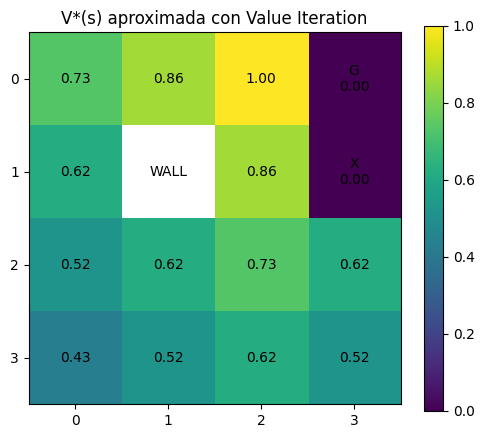

In [25]:
env = DidacticGridWorld()
V_star = value_iteration(env, gamma=0.9)
env.plot_values(V_star, title="V*(s) aproximada con Value Iteration")

Ahora ya no estamos valorando una política concreta.

Estamos aproximando el **valor óptimo** de cada estado.

Eso quiere decir:

- "si a partir de aquí actuase de la mejor forma posible, ¿cuánto valdría estar en este estado?"

## Extraer una política greedy a partir de `V*`

Una vez tenemos `V*`, podemos convertir esos valores en decisiones.

La regla es:

- en cada estado,
- probamos todas las acciones,
- escogemos la que conduce al mejor valor futuro.

In [28]:
def greedy_policy_from_values(env, V, gamma=0.9):
    policy = {}

    for s in env.states:
        if env.is_terminal(s):
            continue

        best_a = None
        best_q = -np.inf

        for a in env.available_actions(s):
            result = env.step_from_state(s, a)
            q = result.reward + gamma * V[result.next_state] * (not result.terminated)

            if q > best_q:
                best_q = q
                best_a = a

        policy[s] = best_a

    return policy

In [29]:
policy_star = greedy_policy_from_values(env, V_star, gamma=0.9)
policy_star_symbols = {s: ARROWS[a] for s, a in policy_star.items()}
env.render_text(policy=policy_star_symbols)

  →     →     →     G  
  ↑   #####   ↑     X  
  ↑     →     ↑     ←  
  A     ↑     ↑     ↑  



Esta política greedy es la traducción práctica de los valores óptimos.

Ya vemos una idea central del RL clásico:

- primero aprendemos valores,
- luego derivamos decisiones a partir de esos valores.

# 11. De `V(s)` a `Q(s,a)`

La función `V(s)` nos dice:

> "qué tal es estar en el estado `s`"

La función `Q(s,a)` va un paso más allá:

> "qué tal es hacer la acción `a` en el estado `s`"

Es decir:

$$
Q^\pi(s,a)
$$

representa el retorno esperado si:

1. estoy en `s`,
2. tomo la acción `a`,
3. y a partir de ahí sigo la política `π`.

## ¿Por qué `Q` es tan útil?

Porque decidir implica comparar acciones.

Con `V(s)` sabemos si un estado es bueno o malo.

Con `Q(s,a)` sabemos cuál acción parece mejor en ese estado.

In [30]:
env = DidacticGridWorld()
state = (3, 2)

for action in env.available_actions(state):
    result = env.step_from_state(state, action)
    print(
        f"Desde {state}, acción={ACTIONS_4[action]:>9s} -> "
        f"siguiente={result.next_state}, recompensa={result.reward:+.2f}, terminado={result.terminated}"
    )

Desde (3, 2), acción=   arriba -> siguiente=(2, 2), recompensa=-0.04, terminado=False
Desde (3, 2), acción=  derecha -> siguiente=(3, 3), recompensa=-0.04, terminado=False
Desde (3, 2), acción=    abajo -> siguiente=(3, 2), recompensa=-0.04, terminado=False
Desde (3, 2), acción=izquierda -> siguiente=(3, 1), recompensa=-0.04, terminado=False


La celda anterior ya nos da una intuición de `Q(s,a)`.

Desde el mismo estado:

- distintas acciones llevan a estados distintos,
- con recompensas distintas,
- y con futuros distintos.

Así que **no basta con valorar el estado**; hay que valorar también la acción.

## Relación entre `V` y `Q`

En RL existen dos formas muy comunes de valorar situaciones:

- **Value function**: cuánto vale un estado  
- **Action-value function**: cuánto vale realizar una acción concreta en ese estado

Estas dos funciones están muy relacionadas.

Recordemos:

- `V(s)` mide **lo bueno que es estar en un estado**.
- `Q(s,a)` mide **lo bueno que es ejecutar una acción concreta desde ese estado**.

Si ya conociéramos la función `Q` óptima (`Q*`), encontrar la política óptima sería trivial.

La política simplemente elegiría **la acción con mayor valor Q** en cada estado:

$$
\pi^*(s) = \arg\max_a Q^*(s,a)
$$

donde:

- `π*(s)` es la **acción óptima en el estado `s`**
- `argmax` significa **la acción que maximiza el valor**

Por ejemplo:

| acción | Q(s,a) |
|------|------|
up | 2.1 |
right | **5.3** |
down | 1.0 |
left | 0.7 |

Entonces:

$$
\pi^*(s) = right
$$

porque es la acción con mayor valor.

---

### Relación entre `V` y `Q`

El valor de un estado también puede obtenerse a partir de `Q`.

Si desde un estado siempre elegimos la mejor acción posible, entonces el valor del estado será simplemente **el mejor valor Q disponible**:

$$
V^*(s) = \max_a Q^*(s,a)
$$

Es decir:

- miramos todas las acciones posibles
- consultamos su valor `Q`
- y nos quedamos con el mayor

---

### Interpretación intuitiva

Podemos pensar que:

- `V(s)` responde a la pregunta  
  > *¿Qué tan bueno es estar aquí?*

- `Q(s,a)` responde a la pregunta  
  > *¿Qué tan buena es esta acción si estoy aquí?*

Por eso `Q` contiene **más información**.

En cierto sentido:

- `V` resume la calidad de un estado
- `Q` descompone esa calidad **por acción**

De hecho, si conocemos `Q*`, podemos obtener todo lo demás:

- la **política óptima**
- el **valor óptimo de los estados**

Esto es una de las razones por las que algoritmos como **Q-learning** intentan aprender directamente `Q(s,a)` en lugar de `V(s)`.

# 12. Q-values a partir de `V*`: pequeña comprobación

Si ya tenemos `V*`, podemos calcular para un estado concreto la cantidad:

$$
Q(s,a) = R_{t+1} + \gamma V(s')
$$

Vamos a hacerlo para unos pocos estados.

In [31]:
env = DidacticGridWorld()
gamma = 0.9

for state in [(3, 0), (2, 2), (0, 2)]:
    print(f"\nEstado {state}")
    for action in env.available_actions(state):
        result = env.step_from_state(state, action)
        q = result.reward + gamma * V_star[result.next_state] * (not result.terminated)
        print(f"  acción={ACTIONS_4[action]:>9s} -> Q aprox = {q: .4f}")


Estado (3, 0)
  acción=   arriba -> Q aprox =  0.4267
  acción=  derecha -> Q aprox =  0.4267
  acción=    abajo -> Q aprox =  0.3440
  acción=izquierda -> Q aprox =  0.3440

Estado (2, 2)
  acción=   arriba -> Q aprox =  0.7340
  acción=  derecha -> Q aprox =  0.5185
  acción=    abajo -> Q aprox =  0.5185
  acción=izquierda -> Q aprox =  0.5185

Estado (0, 2)
  acción=   arriba -> Q aprox =  0.8600
  acción=  derecha -> Q aprox =  1.0000
  acción=    abajo -> Q aprox =  0.7340
  acción=izquierda -> Q aprox =  0.7340


Aquí ya se ve claramente cómo comparar acciones:

- algunas mantienen al agente en el sitio,
- otras lo acercan a la meta,
- otras lo arrastran hacia zonas peores.

La acción con mejor `Q` es, bajo este modelo, la más prometedora.

# 13. Temporal Difference (TD): aprender sin esperar al episodio completo

Hasta ahora hemos usado:

- cuentas manuales,
- policy evaluation iterativa,
- value iteration.

Ahora vamos a acercarnos a los algoritmos de aprendizaje.

## ¿Qué es Temporal Difference (TD) y para qué sirve?

Hasta ahora hemos hablado de **valores de estado**:

$$
V(s)
$$

que representan:

> cuán bueno es estar en un estado si seguimos una política.

Pero hay un problema importante:

**¿Cómo aprendemos esos valores en la práctica?**

Cuando el agente interactúa con el entorno solo observa cosas como:

- el estado actual `s`
- la acción que ejecuta
- la recompensa `r`
- el siguiente estado `s'`

Por ejemplo:

```

estado actual: (2,3)
acción: right
recompensa: -1
nuevo estado: (2,4)

```

El agente **no conoce el valor real de los estados**.  
Tiene que **aprenderlos poco a poco a partir de la experiencia**.

Aquí es donde aparece **Temporal Difference learning (TD)**.

---

# Idea central de TD

La idea es muy simple:

> podemos mejorar nuestra estimación de `V(s)` comparando lo que pensábamos antes con lo que acabamos de observar.

Supongamos que creíamos que:

```

V(2,3) = 4

```

Pero al movernos obtenemos:

```

recompensa = -1
nuevo estado = (2,4)
V(2,4) = 7

```

Entonces podemos estimar que el valor de `(2,3)` debería parecerse más a:

$$
r + \gamma V(s')
$$

porque desde `(2,3)`:

- primero recibimos `r`
- luego estamos en `s'`
- cuyo valor estimado es `V(s')`

---

# Actualización TD(0)

La regla más simple de Temporal Difference es:

$$
V(s) \leftarrow V(s) + \alpha \left[ r + \gamma V(s') - V(s) \right]
$$

Esto significa:

**nuevo valor = valor actual + una corrección**

---

# El error TD

La parte importante es el término:

$$
\delta = r + \gamma V(s') - V(s)
$$

Esto se llama **TD error**.

Mide:

> cuánto se equivocaba nuestra estimación anterior.

Si:

```

r + γV(s') > V(s)

```

entonces **subestimábamos el estado**.

Si:

```

r + γV(s') < V(s)

```

entonces **lo sobreestimábamos**.

---

# ¿Por qué usamos TD?

Porque permite **aprender valores sin conocer el modelo del entorno**.

El agente simplemente:

1. observa transiciones `(s → s')`
2. observa recompensas
3. ajusta sus estimaciones

Esto es exactamente lo que ocurre en RL real.

No necesitamos saber:

- probabilidades de transición
- recompensas esperadas
- dinámica del entorno

Solo necesitamos **experiencia**.

---

# ¿Cuándo ocurre esta actualización?

Cada vez que el agente da **un paso en el entorno**.

El ciclo es:

```

1. estoy en s
2. hago una acción
3. recibo r
4. llego a s'
5. actualizo V(s)

```

Es decir:

**aprendemos continuamente mientras interactuamos con el entorno.**

---

# Por qué TD es tan importante

Temporal Difference es la base de muchos algoritmos famosos:

- SARSA
- Q-learning
- Deep Q-Networks

Todos ellos usan la misma idea:

> actualizar estimaciones usando la diferencia entre predicción y experiencia.

Es el equivalente en RL al **error de predicción** que aparece en muchos algoritmos de aprendizaje.
```




In [34]:
valor_viejo = 0.30
objetivo = 0.80
alpha = 0.10

valor_nuevo = valor_viejo + alpha * (objetivo - valor_viejo)
valor_nuevo

0.35

En este ejemplo:

- pensábamos que el valor era `0.30`,
- nueva evidencia sugiere un objetivo de `0.80`,
- no saltamos de golpe a `0.80`,
- sino que nos movemos parcialmente hacia allí.

Eso hace el aprendizaje más gradual y estable.

## TD para valores de estado

La actualización más simple de **Temporal Difference**, conocida como **TD(0)**, para valores de estado es:

$$
V(s) \leftarrow V(s) + \alpha \left[ r + \gamma V(s') - V(s) \right]
$$

Vamos a entender qué significa exactamente esta expresión.

---

### Descomposición de la fórmula

La actualización tiene tres partes muy claras:

1. **Valor actual**
   
   $$
   V(s)
   $$

   Es nuestra estimación actual de cuánto vale el estado.

2. **Término de corrección**

   $$
   \alpha \left[ r + \gamma V(s') - V(s) \right]
   $$

   Es el ajuste que aplicamos.

3. **Error TD (Temporal Difference error)**

   La parte dentro del corchete:

   $$
   \delta = r + \gamma V(s') - V(s)
   $$

   se llama **TD error**.

---

### Interpretación intuitiva

La ecuación dice:

> Nuevo valor = valor actual + un pequeño ajuste basado en la experiencia reciente.

Y ese ajuste depende de:

- la recompensa inmediata `r`,
- el valor estimado del siguiente estado `V(s')`,
- lo que pensábamos antes que valía `V(s)`.

Si el resultado `r + γV(s')` es mayor de lo que esperábamos, el error será positivo → aumentamos el valor.

Si es menor → el error será negativo → reducimos el valor.

---

### ¿Por qué se llama Temporal Difference?

Porque estamos comparando:

- una estimación en el tiempo `t`:  
  $$
  V(s)
  $$

con

- una estimación basada en el tiempo `t+1`:  
  $$
  r + \gamma V(s')
  $$

Es decir, aprendemos comparando dos estimaciones separadas en el tiempo.

---

### Rol de cada parámetro

- `α` (learning rate):
  - controla cuánto aprendemos de esta experiencia
  - si es muy grande → aprendizaje rápido pero inestable
  - si es pequeño → aprendizaje más lento pero más estable

- `γ` (discount factor):
  - controla cuánto valoramos el futuro

---

### Idea clave

TD(0) es potente porque:

- no necesita esperar al final del episodio
- aprende paso a paso
- mezcla bootstrap (usar estimaciones actuales) con experiencia real

Es el puente entre:
- Monte Carlo (esperar al final)
- métodos totalmente basados en modelo

Y es la base de:
- SARSA
- Q-learning
- Deep Q-Networks

In [33]:
V_s = 0.20
reward = -0.04
gamma = 0.9
V_s_next = 0.70
alpha = 0.1

target = reward + gamma * V_s_next
td_error = target - V_s
updated = V_s + alpha * td_error

print("target  =", round(target, 4))
print("td_error=", round(td_error, 4))
print("nuevo V =", round(updated, 4))

target  = 0.59
td_error= 0.39
nuevo V = 0.239


Fíjate en la estructura porque la vamos a reutilizar enseguida con `Q`.

Solo cambiaremos:

- en vez de `V(s)`, usaremos `Q(s,a)`,
- y el objetivo dependerá del algoritmo concreto.

# 14. Exploración vs explotación otra vez: entra `epsilon`-greedy

Cuando ya tenemos una tabla `Q`, ¿cómo decide el agente?

Una estrategia muy habitual es **ε-greedy**:

- con probabilidad `epsilon`, explora (elige una acción aleatoria),
- con probabilidad `1 - epsilon`, explota (elige la mejor acción conocida).

Esto evita que el agente se quede demasiado pronto atrapado en una solución mediocre.

In [35]:
def epsilon_greedy_action(Q, state, epsilon=0.1, n_actions=4):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    else:
        return int(np.argmax(Q[state]))

In [36]:
np.random.seed(7)

Q_demo = np.zeros((4, 4, 4))
Q_demo[3, 0] = [0.10, 0.80, 0.05, 0.02]

state = (3, 0)
acciones = [epsilon_greedy_action(Q_demo, state, epsilon=0.3, n_actions=4) for _ in range(20)]
[ACTIONS_4[a] for a in acciones]

['derecha',
 'derecha',
 'derecha',
 'derecha',
 'derecha',
 'derecha',
 'abajo',
 'abajo',
 'derecha',
 'derecha',
 'derecha',
 'abajo',
 'derecha',
 'derecha',
 'derecha',
 'derecha',
 'arriba',
 'derecha',
 'derecha',
 'abajo']

En esa lista seguramente verás que:

- muchas veces sale la acción con mejor `Q` (probablemente `derecha`),
- pero a veces aparecen otras por exploración.

Eso es exactamente lo que queremos.

# 15. SARSA: aprender la Q de la política que realmente sigo

SARSA significa:

- **S**tate
- **A**ction
- **R**eward
- **S**tate
- **A**ction

porque la actualización usa la secuencia:

$$
(s, a, r, s', a')
$$

Su regla es:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma Q(s',a') - Q(s,a) \right]
$$

## Idea conceptual

SARSA aprende el valor de la política que **de verdad está ejecutando**.

Si esa política es `epsilon`-greedy, entonces SARSA aprende teniendo en cuenta que a veces explorará y cometerá acciones subóptimas.

Por eso solemos decir que SARSA es más **on-policy**.

Primero te **arreglo la fórmula** (se han roto `\alpha` y `\right]`) y luego te dejo una explicación clara de **cada término**, en formato listo para un notebook.

---


## Actualización de SARSA

Una forma de aprender los valores `Q(s,a)` directamente es usando **SARSA**, un algoritmo basado en *Temporal Difference learning*.

La regla de actualización es:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma Q(s',a') - Q(s,a) \right]
$$

Esta ecuación nos dice cómo ajustar nuestra estimación del valor de una acción después de observar una transición en el entorno.

---

# Significado de cada término

### $Q(s,a)$

Es nuestra **estimación actual** del valor de ejecutar la acción `a` en el estado `s`.

Responde a la pregunta:

> ¿Qué tan buena es esta acción si estoy en este estado?

---

### $r$

Es la **recompensa inmediata** recibida tras ejecutar la acción `a`.

Ejemplo típico en un gridworld:

| transición | recompensa |
|---|---|
moverse | -1 |
llegar a meta | +10 |
caer en trampa | -10 |

---

### $s'$

Es el **nuevo estado** al que llegamos después de ejecutar la acción.

Ejemplo:

```

estado actual: (2,3)
acción: right
nuevo estado: (2,4)

```

---

### $a'$

Es la **siguiente acción que el agente decide ejecutar desde el nuevo estado**.

Esto es importante: en **SARSA**, la actualización usa **la acción que realmente se va a ejecutar**.

Por eso el nombre del algoritmo:

```

State
Action
Reward
State
Action

```

---

### $ \gamma $

Es el **discount factor**.

Controla cuánto valoramos las recompensas futuras.

$$
0 \le \gamma < 1
$$

Valores típicos:

| γ | significado |
|---|---|
0.5 | futuro poco importante |
0.9 | futuro bastante importante |
0.99 | futuro casi tan importante como el presente |

---

### $ \alpha $

Es el **learning rate**.

Controla cuánto modificamos nuestra estimación en cada actualización.

$$
0 < \alpha \le 1
$$

Si:

- `α` grande → aprendizaje rápido pero inestable  
- `α` pequeño → aprendizaje más lento pero más estable

---

# El error TD

La parte dentro del corchete:

$$
r + \gamma Q(s',a') - Q(s,a)
$$

se llama **TD error**.

Mide la diferencia entre:

- lo que pensábamos que valía `(s,a)`
- lo que sugiere la experiencia reciente

Si el error es positivo → aumentamos el valor.

Si es negativo → lo reducimos.

---

# Interpretación intuitiva

La ecuación dice:

> ajustamos el valor de una acción basándonos en la recompensa obtenida y en lo prometedor que parece el siguiente estado.

En palabras simples:

1. el agente ejecuta una acción
2. observa recompensa y nuevo estado
3. decide una nueva acción
4. usa esa información para corregir su estimación

Este proceso se repite continuamente mientras el agente interactúa con el entorno.

---

# Idea clave

SARSA aprende evaluando **la política que realmente está siguiendo el agente**.

Por eso se dice que es un algoritmo **on-policy**.


## Mini ejemplo numérico de SARSA

In [37]:
Q_sa = 0.40
reward = -0.04
gamma = 0.9
Q_siguiente_accion = 0.70
alpha = 0.1

target = reward + gamma * Q_siguiente_accion
nuevo_Q = Q_sa + alpha * (target - Q_sa)

print("target =", round(target, 4))
print("nuevo_Q =", round(nuevo_Q, 4))

target = 0.59
nuevo_Q = 0.419


Observa el objetivo de SARSA:

$$
r + \gamma Q(s', a')
$$

No usa "la mejor acción posible" del siguiente estado.

Usa **la acción que realmente voy a tomar** después según mi política actual.

# 16. Q-learning: aprender hacia la mejor acción futura

Q-learning es muy parecido a SARSA, pero cambia **una sola pieza** del objetivo.

La regla de actualización es:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]
$$

La diferencia parece pequeña, pero sus consecuencias son enormes.

---

## Antes: ¿qué es una Q-table?

Cuando el entorno tiene **pocos estados** y **pocas acciones** (por ejemplo un gridworld pequeño), podemos guardar `Q(s,a)` en una tabla:

- filas: estados `s`
- columnas: acciones `a`
- celda: "valor estimado" de hacer esa acción en ese estado

A esto se le llama **Q-table**.

Ejemplo conceptual:

| Estado $s$ | up | right | down | left |
|---|---:|---:|---:|---:|
| (0,0) | 0.1 | 0.3 | -0.2 | 0.0 |
| (0,1) | 0.0 | 0.4 | -0.1 | 0.2 |
| ... | ... | ... | ... | ... |

Interpretación:
- si `Q((0,1), right) = 0.4`, significa que (según lo aprendido hasta ahora) **ir a la derecha** desde `(0,1)` es una opción bastante buena.

> Importante: al inicio la Q-table suele estar llena de ceros (o valores aleatorios pequeños) y se va “pintando” con experiencia.

---

## Términos de la ecuación (uno por uno)

Repetimos la ecuación:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]
$$

### $s$ y $a$
- $s$: **estado actual** (por ejemplo, la celda donde está el agente)
- $a$: **acción ejecutada** en ese estado (up/right/down/left)

### $Q(s,a)$
- nuestro valor estimado actual de la pareja (estado, acción)
- responde a: *“¿qué tal es hacer `a` si estoy en `s`?”*

### $r$
- **recompensa inmediata** observada al ejecutar la acción
- ejemplo típico en gridworld: moverse = -1, llegar a meta = +10, caer = -100

### $s'$
- **nuevo estado** al que llegamos después de ejecutar $a$

### $\max_{a'} Q(s',a')$
- esto es la clave de Q-learning:
  - miramos el **siguiente estado** $s'$
  - evaluamos todas las acciones posibles desde ahí
  - nos quedamos con el valor de **la mejor** (según la Q-table actual)

Es decir, Q-learning pregunta:

> “Si desde $s'$ yo eligiera la mejor acción posible, ¿cuánto podría conseguir?”

### $\gamma$ (discount factor)
- cuánto nos importan recompensas futuras:
  - $\gamma$ cerca de 0 → miopía (importa el corto plazo)
  - $\gamma$ cerca de 1 → planifica a largo plazo

### $\alpha$ (learning rate)
- cuánto corregimos nuestra estimación:
  - $\alpha$ grande → aprende rápido pero puede oscilar
  - $\alpha$ pequeño → aprende lento pero estable

---

## El TD error (la pieza conceptual más importante)

El término dentro del corchete:

$$
\delta = r + \gamma \max_{a'} Q(s',a') - Q(s,a)
$$

se llama **TD error**.

Mide:

> diferencia entre lo que pensábamos que valía $Q(s,a)$ y lo que sugiere la experiencia reciente + el mejor futuro posible.

- Si $\delta > 0$: subestimábamos → subimos $Q(s,a)$
- Si $\delta < 0$: sobreestimábamos → bajamos $Q(s,a)$

Y la actualización completa es:

> $Q$ nuevo = $Q$ viejo + (paso de aprendizaje) × (error)

---

## Intuición: por qué Q-learning es off-policy

Q-learning **no usa** “la acción que realmente haré después” (como SARSA).

En su lugar usa:

$$
\max_{a'} Q(s',a')
$$

o sea, usa *“la mejor acción posible”* según la tabla.

Eso significa que:

- el agente puede comportarse de forma exploratoria (ε-greedy),
- pero **aprende como si fuera perfecto** en el siguiente paso (elige el mejor $a'$).

Por eso decimos que Q-learning es **off-policy**:
- el *behavior policy* (cómo actúo) puede explorar,
- pero el *target* (cómo actualizo) mira a la política greedy (la mejor).

---

# Mini-explicación: SARSA vs Q-learning (intuición + ejemplo)

Ambos actualizan $Q(s,a)$, pero la diferencia está en el objetivo:

### SARSA (on-policy)
$$
Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma Q(s',a') - Q(s,a)\right]
$$

- usa la acción $a'$ **que realmente va a ejecutar** (incluyendo exploración)
- aprende el valor de **su comportamiento real**

### Q-learning (off-policy)
$$
Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma \max_{a'}Q(s',a') - Q(s,a)\right]
$$

- usa la **mejor acción posible** en $s'$, aunque el agente no la elija realmente
- aprende “tirando hacia” la política óptima

---

## ¿Por qué importa esto en un gridworld?

Imagina un **cliff gridworld** (clásico):

- hay una ruta corta pegada al borde de un acantilado (mucho riesgo)
- caer al cliff da una recompensa muy negativa
- la ruta segura es un poco más larga

**Con exploración (ε-greedy):**
- el agente a veces hará movimientos aleatorios (por exploración)

### Qué suele pasar:
- **SARSA** tiende a aprender una política más **segura**  
  porque su actualización tiene en cuenta que *“a veces haré una acción mala por explorar”*.

- **Q-learning** tiende a aprender la ruta más **agresiva/corta**  
  porque actualiza como si en el futuro siempre fuera a escoger la mejor acción, ignorando el riesgo de exploración.

Dicho de otra forma:

- SARSA: “valoro lo que me pasa de verdad (con mis errores)”
- Q-learning: “aprendo como si yo fuera perfecto eligiendo después”

---

## Resumen en 1 frase

- **SARSA** aprende la política que está ejecutando (incluyendo exploración).
- **Q-learning** aprende la política greedy óptima aunque explore durante el entrenamiento.

In [38]:
Q_sa = 0.40
reward = -0.04
gamma = 0.9
max_Q_siguiente = 0.95
alpha = 0.1

target = reward + gamma * max_Q_siguiente
nuevo_Q = Q_sa + alpha * (target - Q_sa)

print("target =", round(target, 4))
print("nuevo_Q =", round(nuevo_Q, 4))

target = 0.815
nuevo_Q = 0.4415


Comparando con SARSA:

- si la acción realmente elegida `a'` no era la mejor,
- entonces SARSA usará un objetivo más conservador,
- mientras que Q-learning mirará hacia la mejor acción estimada.

En muchos entornos esto hace a Q-learning más agresivo u optimista.

# 17. El entorno ideal para comparar SARSA y Q-learning: Cliff Grid

Vamos a usar ahora un entorno clásico y muy didáctico.

Tiene:

- una casilla inicial,
- una meta al otro extremo,
- y entre medias un "precipicio" o *cliff*.

La situación típica es esta:

- el camino pegado al precipicio es más corto,
- pero si exploras mal, puedes caer y recibir una penalización enorme;
- el camino más alejado es más largo, pero mucho más seguro.

Este entorno muestra muy bien la diferencia entre:

- un método que aprende teniendo en cuenta su exploración real (SARSA),
- y uno que aprende hacia la política greedy óptima (Q-learning).

In [39]:
class CliffGridWorld:
    def __init__(self, rows=4, cols=12, step_cost=-1.0, cliff_reward=-100.0):
        self.rows = rows
        self.cols = cols
        self.step_cost = step_cost
        self.cliff_reward = cliff_reward

        self.start = (rows - 1, 0)
        self.goal = (rows - 1, cols - 1)
        self.cliff = {(rows - 1, c) for c in range(1, cols - 1)}

        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def is_terminal(self, state):
        return state == self.goal

    def step(self, action):
        dr, dc = DELTA_4[action]
        nr, nc = self.state[0] + dr, self.state[1] + dc

        if not (0 <= nr < self.rows and 0 <= nc < self.cols):
            nr, nc = self.state

        next_state = (nr, nc)

        if next_state in self.cliff:
            self.state = self.start
            return self.state, self.cliff_reward, False

        self.state = next_state

        if self.state == self.goal:
            return self.state, 0.0, True

        return self.state, self.step_cost, False

    def render_text(self):
        for r in range(self.rows):
            row = []
            for c in range(self.cols):
                s = (r, c)
                if s == self.state:
                    row.append("A")
                elif s == self.start:
                    row.append("S")
                elif s == self.goal:
                    row.append("G")
                elif s in self.cliff:
                    row.append("X")
                else:
                    row.append(".")
            print(" ".join(row))
        print()

In [40]:
cliff_env = CliffGridWorld()
cliff_env.reset()
cliff_env.render_text()

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
A X X X X X X X X X X G



La fila inferior tiene:

- `S` al principio,
- `G` al final,
- y muchas casillas `X` que son el precipicio.

Ir pegado al borde puede ser eficiente, pero explorando con `epsilon`-greedy es arriesgado.

# 18. Implementación de SARSA

Vamos a implementarlo con una tabla `Q` de dimensiones:

- filas,
- columnas,
- acciones.

El algoritmo, de forma resumida, hará esto en cada episodio:

1. resetea entorno,
2. elige primera acción con `epsilon`-greedy,
3. ejecuta acción,
4. observa recompensa y siguiente estado,
5. elige la siguiente acción también con `epsilon`-greedy,
6. actualiza `Q(s,a)` con la regla SARSA.

In [41]:
def train_sarsa(env, episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1, max_steps=10_000):
    Q = np.zeros((env.rows, env.cols, 4))
    returns = []

    for episode in range(episodes):
        state = env.reset()
        action = epsilon_greedy_action(Q, state, epsilon=epsilon, n_actions=4)

        episode_return = 0.0

        for _ in range(max_steps):
            next_state, reward, terminated = env.step(action)
            episode_return += reward

            if terminated:
                td_target = reward
                Q[state][action] += alpha * (td_target - Q[state][action])
                break

            next_action = epsilon_greedy_action(Q, next_state, epsilon=epsilon, n_actions=4)
            td_target = reward + gamma * Q[next_state][next_action]
            Q[state][action] += alpha * (td_target - Q[state][action])

            state = next_state
            action = next_action

        returns.append(episode_return)

    return Q, returns

# 19. Implementación de Q-learning

La estructura será casi idéntica.

La diferencia clave está en el objetivo:

$$
r + \gamma \max_{a'} Q(s', a')
$$

En vez de usar la acción realmente elegida después, usa la mejor acción estimada.

In [42]:
def train_q_learning(env, episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1, max_steps=10_000):
    Q = np.zeros((env.rows, env.cols, 4))
    returns = []

    for episode in range(episodes):
        state = env.reset()
        episode_return = 0.0

        for _ in range(max_steps):
            action = epsilon_greedy_action(Q, state, epsilon=epsilon, n_actions=4)
            next_state, reward, terminated = env.step(action)
            episode_return += reward

            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * np.max(Q[next_state])

            Q[state][action] += alpha * (td_target - Q[state][action])

            state = next_state

            if terminated:
                break

        returns.append(episode_return)

    return Q, returns

# 20. Entrenamos ambos algoritmos

Usaremos los mismos hiperparámetros para tener una comparación razonable.

In [43]:
np.random.seed(42)

episodes = 500
alpha = 0.5
gamma = 1.0
epsilon = 0.1

env_sarsa = CliffGridWorld()
Q_sarsa, returns_sarsa = train_sarsa(env_sarsa, episodes=episodes, alpha=alpha, gamma=gamma, epsilon=epsilon)

env_q = CliffGridWorld()
Q_q, returns_q = train_q_learning(env_q, episodes=episodes, alpha=alpha, gamma=gamma, epsilon=epsilon)

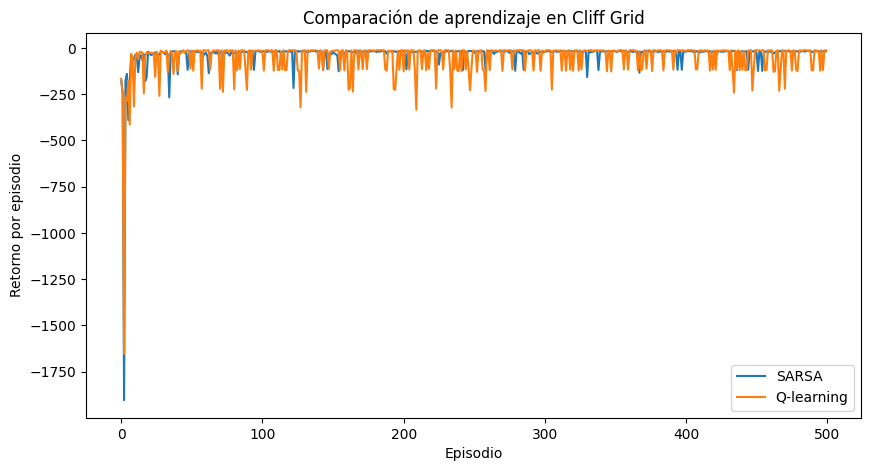

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(returns_sarsa, label="SARSA")
plt.plot(returns_q, label="Q-learning")
plt.xlabel("Episodio")
plt.ylabel("Retorno por episodio")
plt.title("Comparación de aprendizaje en Cliff Grid")
plt.legend()
plt.show()

La gráfica anterior suele mostrar bastante ruido, porque RL aprende a partir de experiencia y la exploración mete variabilidad.

Aun así, suele apreciarse una diferencia de comportamiento global.

Para verlo más claro, vamos a suavizar con una media móvil.

In [45]:
def moving_average(x, window=20):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

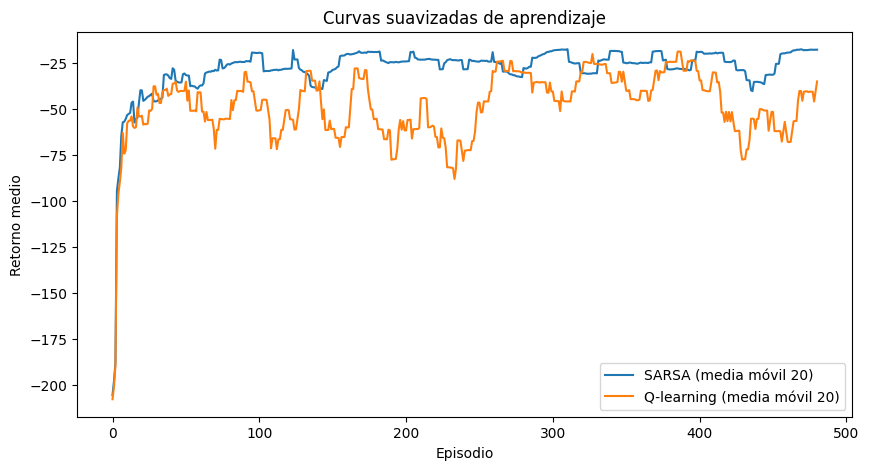

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(moving_average(returns_sarsa, 20), label="SARSA (media móvil 20)")
plt.plot(moving_average(returns_q, 20), label="Q-learning (media móvil 20)")
plt.xlabel("Episodio")
plt.ylabel("Retorno medio")
plt.title("Curvas suavizadas de aprendizaje")
plt.legend()
plt.show()

## Interpretación esperada

En este entorno, muy a menudo ocurre algo como esto:

- **Q-learning** aprende la ruta más corta pegada al precipicio,
- **SARSA** tiende a preferir una ruta más segura.

¿Por qué?

Porque SARSA tiene en cuenta que durante la exploración `epsilon`-greedy podría cometer errores y caer al precipicio.

Q-learning, en cambio, actualiza mirando a la acción óptima estimada futura, como si después fuese a comportarse de forma ideal.

# 21. Extraer y visualizar la política aprendida

Vamos a ver qué acción prefiere cada algoritmo en cada celda.

In [47]:
def greedy_policy_from_q(Q):
    policy = {}
    rows, cols, _ = Q.shape
    for r in range(rows):
        for c in range(cols):
            policy[(r, c)] = int(np.argmax(Q[r, c]))
    return policy

In [48]:
def render_cliff_policy(policy, env):
    for r in range(env.rows):
        row = []
        for c in range(env.cols):
            s = (r, c)
            if s == env.start:
                row.append("S")
            elif s == env.goal:
                row.append("G")
            elif s in env.cliff:
                row.append("X")
            else:
                row.append(ARROWS[policy[s]])
        print(" ".join(row))
    print()

In [49]:
policy_sarsa = greedy_policy_from_q(Q_sarsa)
policy_q = greedy_policy_from_q(Q_q)

print("Política greedy derivada de SARSA:")
render_cliff_policy(policy_sarsa, CliffGridWorld())

print("Política greedy derivada de Q-learning:")
render_cliff_policy(policy_q, CliffGridWorld())

Política greedy derivada de SARSA:
→ → → → → → → → → → → ↓
↑ ↑ ↑ → → → ↑ ↑ ↑ ↑ ↑ ↓
↑ ↑ ← ↑ ↑ ↑ ↑ ↑ → → → ↓
S X X X X X X X X X X G

Política greedy derivada de Q-learning:
→ ← → → → → → → → → ↓ ↓
↑ → → ↓ → → → ↓ → → → ↓
→ → → → → → → → → → → ↓
S X X X X X X X X X X G



In [60]:
from IPython.display import clear_output
import time

def render_cliff_with_trail(env, trail=None):
    """Renderiza CliffGridWorld en texto. Si trail es un set de estados, los marca con '·'."""
    trail = trail or set()
    for r in range(env.rows):
        row = []
        for c in range(env.cols):
            s = (r, c)
            if s == env.state:
                row.append("A")          # Agente
            elif s == env.start:
                row.append("S")          # Start
            elif s == env.goal:
                row.append("G")          # Goal
            elif s in env.cliff:
                row.append("X")          # Cliff
            elif s in trail:
                row.append("·")          # Camino recorrido
            else:
                row.append(".")
        print(" ".join(row))
    print()

def animate_policy_cliff(policy, env=None, sleep=0.15, max_steps=200, title=""):
    """
    Anima un episodio siguiendo una policy greedy (dict: state -> action)
    en CliffGridWorld, mostrando el movimiento del agente paso a paso.
    """
    env = env or CliffGridWorld()
    state = env.reset()

    trail = set([state])
    total_return = 0.0

    for t in range(max_steps):
        action = policy[state]  # acción greedy para ese estado
        next_state, reward, terminated = env.step(action)
        total_return += reward

        trail.add(next_state)

        clear_output(wait=True)
        print(title)
        print(f"Paso {t+1:03d} | s={state} | a={ACTIONS_4[action]} {ARROWS[action]} | r={reward:6.1f} | retorno={total_return:7.1f}")
        render_cliff_with_trail(env, trail=trail)

        time.sleep(sleep)

        state = next_state
        if terminated:
            print("✅ Llegó a la meta (G).")
            break
    else:
        print("⚠️ Alcanzado max_steps sin llegar a la meta.")

In [62]:
animate_policy_cliff(
    policy_sarsa,
    env=CliffGridWorld(),
    sleep=0.20,
    max_steps=200,
    title="Animación siguiendo política greedy derivada de SARSA"
)

Animación siguiendo política greedy derivada de SARSA
Paso 017 | s=(2, 11) | a=abajo ↓ | r=   0.0 | retorno=  -16.0
· · · · · · · · · · · ·
· . . . . . . . . . . ·
· . . . . . . . . . . ·
S X X X X X X X X X X A

✅ Llegó a la meta (G).


In [63]:
animate_policy_cliff(
    policy_q,
    env=CliffGridWorld(),
    sleep=0.30,
    max_steps=200,
    title="Animación siguiendo política greedy derivada de Q-learning"
)

Animación siguiendo política greedy derivada de Q-learning
Paso 013 | s=(2, 11) | a=abajo ↓ | r=   0.0 | retorno=  -12.0
. . . . . . . . . . . .
. . . . . . . . . . . .
· · · · · · · · · · · ·
S X X X X X X X X X X A

✅ Llegó a la meta (G).



No estamos mirando solo números: estamos mirando **comportamiento aprendido**.

### Qué deberías observar

- Si SARSA dibuja una ruta más separada del precipicio, está siendo más prudente.
- Si Q-learning va pegado al borde, está apostando por el camino corto óptimo.

# 22. Un episodio greedy paso a paso

Vamos a ejecutar la política greedy de cada algoritmo sin exploración para ver su trayectoria.

In [50]:
def rollout_greedy(env, Q, max_steps=100):
    state = env.reset()
    path = [state]
    total_reward = 0.0

    for _ in range(max_steps):
        action = int(np.argmax(Q[state]))
        next_state, reward, terminated = env.step(action)
        total_reward += reward
        path.append(next_state)
        state = next_state
        if terminated:
            break
        

    return path, total_reward

In [51]:
path_sarsa, reward_sarsa = rollout_greedy(CliffGridWorld(), Q_sarsa)
path_q, reward_q = rollout_greedy(CliffGridWorld(), Q_q)

print("Trayectoria greedy SARSA:")
print(path_sarsa)
print("Retorno total:", reward_sarsa)

print("\nTrayectoria greedy Q-learning:")
print(path_q)
print("Retorno total:", reward_q)

Trayectoria greedy SARSA:
[(3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (2, 11), (3, 11)]
Retorno total: -16.0

Trayectoria greedy Q-learning:
[(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)]
Retorno total: -12.0


Esta inspección secuencial ayuda mucho porque:

- una política como flechas en una rejilla es útil,
- pero una trayectoria concreta deja aún más claro qué está haciendo realmente el agente.

# 23. Hiperparámetros: qué papel juegan `alpha`, `gamma` y `epsilon`

## `alpha` · learning rate

Controla cuánto corregimos los valores cuando llega nueva evidencia.

- `alpha` alto: aprendizaje rápido pero más inestable
- `alpha` bajo: aprendizaje más lento pero más suave

## `gamma` · discount factor

Controla cuánto pesa el futuro.

- `gamma` bajo: agente más miope
- `gamma` alto: agente más orientado al largo plazo

## `epsilon` · exploración

Controla cuánta aleatoriedad metemos en la selección de acciones.

- `epsilon` alto: mucha exploración
- `epsilon` bajo: más explotación

Vamos a hacer pequeños experimentos.

In [52]:
def quick_experiment(epsilon_values, episodes=200):
    results = {}
    for eps in epsilon_values:
        np.random.seed(42)
        _, returns = train_q_learning(CliffGridWorld(), episodes=episodes, alpha=0.5, gamma=1.0, epsilon=eps)
        results[eps] = moving_average(returns, 20)
    return results

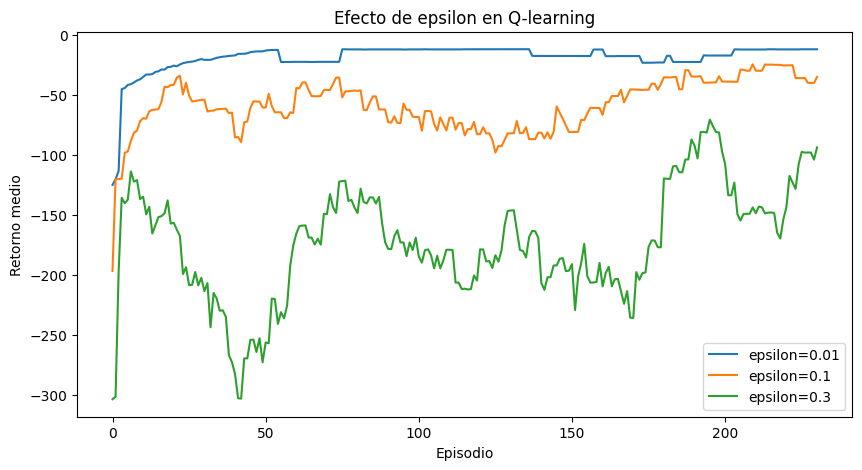

In [53]:
results_eps = quick_experiment([0.01, 0.1, 0.3], episodes=250)

plt.figure(figsize=(10, 5))
for eps, curve in results_eps.items():
    plt.plot(curve, label=f"epsilon={eps}")
plt.xlabel("Episodio")
plt.ylabel("Retorno medio")
plt.title("Efecto de epsilon en Q-learning")
plt.legend()
plt.show()

### Cómo interpretar esta gráfica

- con `epsilon` muy bajo, el agente explora poco;
- puede converger antes, pero corre el riesgo de no descubrir buenas rutas;
- con `epsilon` alto, explora más, pero durante más tiempo puede cometer errores costosos.

En RL casi nunca existe un hiperparámetro "mágico".  
Suele haber equilibrio entre velocidad, estabilidad y calidad de la solución.

## Decaimiento de `epsilon`

En muchos problemas no queremos dejar `epsilon` fijo.

Una estrategia muy habitual es:

- explorar bastante al principio,
- ir reduciendo `epsilon` poco a poco,
- y terminar explotando más lo aprendido.

In [54]:
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.97

valores = []
for _ in range(20):
    valores.append(epsilon)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

valores

[1.0,
 0.97,
 0.9409,
 0.912673,
 0.8852928099999999,
 0.8587340256999999,
 0.8329720049289999,
 0.8079828447811299,
 0.783743359437696,
 0.7602310586545651,
 0.7374241268949281,
 0.7153014030880802,
 0.6938423609954378,
 0.6730270901655747,
 0.6528362774606075,
 0.6332511891367892,
 0.6142536534626856,
 0.595826043858805,
 0.5779512625430409,
 0.5606127246667496]

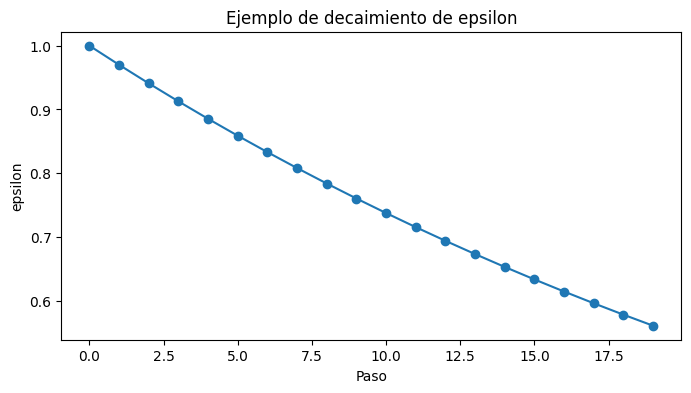

In [55]:
plt.figure(figsize=(8, 4))
plt.plot(valores, marker="o")
plt.xlabel("Paso")
plt.ylabel("epsilon")
plt.title("Ejemplo de decaimiento de epsilon")
plt.show()

# 24. Una implementación de Q-learning con decaimiento de `epsilon`

Vamos a incorporar esa idea porque en la práctica se usa muchísimo.

In [56]:
def train_q_learning_decay(env, episodes=500, alpha=0.5, gamma=1.0,
                           epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.995,
                           max_steps=10_000):
    Q = np.zeros((env.rows, env.cols, 4))
    returns = []
    epsilons = []

    epsilon = epsilon_start

    for episode in range(episodes):
        state = env.reset()
        episode_return = 0.0

        for _ in range(max_steps):
            action = epsilon_greedy_action(Q, state, epsilon=epsilon, n_actions=4)
            next_state, reward, terminated = env.step(action)
            episode_return += reward

            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * np.max(Q[next_state])

            Q[state][action] += alpha * (td_target - Q[state][action])
            state = next_state

            if terminated:
                break

        returns.append(episode_return)
        epsilons.append(epsilon)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, returns, epsilons

In [57]:
np.random.seed(42)
Q_decay, returns_decay, epsilons_decay = train_q_learning_decay(
    CliffGridWorld(),
    episodes=400,
    alpha=0.5,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.985
)

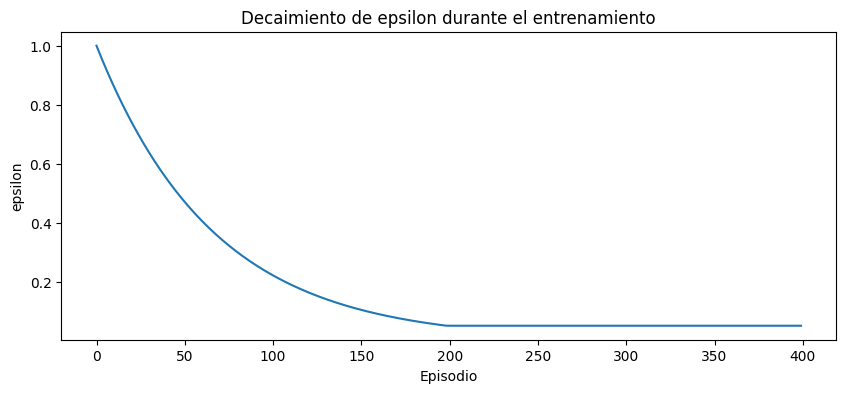

In [58]:
plt.figure(figsize=(10, 4))
plt.plot(epsilons_decay)
plt.xlabel("Episodio")
plt.ylabel("epsilon")
plt.title("Decaimiento de epsilon durante el entrenamiento")
plt.show()

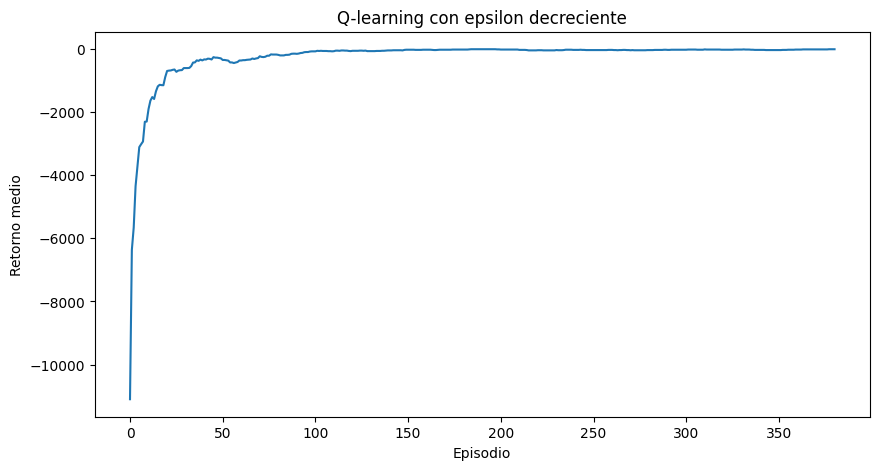

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(moving_average(returns_decay, 20))
plt.xlabel("Episodio")
plt.ylabel("Retorno medio")
plt.title("Q-learning con epsilon decreciente")
plt.show()

En muchos casos esta estrategia mejora el comportamiento porque:

- al principio permite descubrir el entorno,
- y más tarde deja que el agente consolide una política razonable.

# 25. Resumen conceptual de la sesión

Vamos a recoger las ideas clave.

## 1) `V(s)` y `Q(s,a)` no son recompensas inmediatas

Son estimaciones de **retorno esperado futuro**.

- `V(s)`: qué tan bueno es estar en un estado
- `Q(s,a)`: qué tan buena es una acción concreta en un estado

## 2) Bellman es la idea central

El valor de ahora se puede expresar como:

- recompensa inmediata
- más valor futuro descontado

## 3) Aprender consiste en corregir estimaciones

Con TD hacemos actualizaciones incrementales usando:

- lo que creíamos antes,
- y un objetivo provisional basado en nueva experiencia.

## 4) SARSA y Q-learning se parecen, pero no son lo mismo

- **SARSA**: aprende la política que realmente sigue (`on-policy`)
- **Q-learning**: aprende hacia la mejor acción futura estimada (`off-policy`)

## 5) La exploración importa muchísimo

Con `epsilon`-greedy el agente no se queda siempre con lo que ya cree saber.

Eso es necesario para descubrir mejores trayectorias, aunque también introduce riesgo.

# 26. Ideas-fuerza que merece la pena recordar

Si te quedas solo con unas pocas frases de hoy, que sean estas:

1. **El reward inmediato no basta**: RL vive del equilibrio entre presente y futuro.
2. **Bellman propaga promesa de futuro hacia atrás**.
3. **Q-learning compara acciones**, no solo estados.
4. **Explorar es necesario**, aunque empeore temporalmente el rendimiento.
5. **Dos algoritmos muy parecidos pueden inducir comportamientos distintos**.

https://huggingface.co/learn/deep-rl-course/unit2/hands-on